<h1 align="center"><b>Homework Assignment 2 (100 points total)</b></h1>
<h3 align="center"><b>Assigned at the start of Module 3</b></h3>
<h3 align="center"><b>Due at the end of Module 5</b></h3><br>

#### Author: Robert Feconda
#### email: rfecond1@jh.edu

# Q1 — Dynamic Programming: Longest Palindromic Subsequence

## 30 points total

### [15 points] Part A: Implement the Algorithm

Write a dynamic programming solution that computes both:
- The **length** of the longest palindromic subsequence (LPS) in a given string `s`
- The **actual subsequence string** itself

You must:
- Use a **bottom-up (iterative)** dynamic programming approach (not recursion)
- Use a 2D `dp` table where `dp[i][j]` stores the length of the LPS in substring `s[i...j]`
- Include a **traceback routine** to reconstruct one longest palindromic subsequence

Your function should follow this signature:

```python
def longest_palindromic_subsequence(s: str) -> tuple[int, str]:
    pass
```

**A sample input and output is below**

```python

s = "bbbab"
dp[0][4] = 4

Traceback path (example):

s[0] = 'b', s[4] = 'b' → match → result = ['b' ... 'b']
    dp[1][3] = 2
s[1] = 'b', s[3] = 'b' → match → result = ['b', 'b' ... 'b', 'b']
    dp[2][2] = 1 (base case)
Final result: "bbbb"
```

### [15 points] Part B: Analyze and Explain

In markdown cells in your notebook, complete the following:

#### Recurrence Relation

Let `dp[i][j]` represent the length of the longest palindromic subsequence in `s[i...j]`.  
Write out the recurrence for the following cases:

- If `s[i] == s[j]`
- If `s[i] != s[j]`

#### Base Cases

- What value should `dp[i][i]` have for all `i`?

#### Time and Space Complexity

- Derive the **time complexity** in terms of `n = len(s)`
- Derive the **space complexity**
- Explain your reasoning clearly

#### Traceback Explanation

- Describe in words how you reconstructed the actual palindrome string
- Where in the table did you start, and how did you decide to move?


In [46]:
def longest_palindromic_subsequence(s: str, verbose: bool = False) -> tuple[int, str]:
    string_length = len(s)
    if string_length == 0:
        if verbose:
            print("Traceback path: <empty string>")
        return 0, ""

    # lps_length_table[start][end] = LPS length inside s[start..end]
    lps_length_table = [[0] * string_length for _ in range(string_length)]

    # Base case: one character is a palindrome of length 1.
    for index in range(string_length):
        lps_length_table[index][index] = 1

    # Build larger windows from smaller windows.
    for window_length in range(2, string_length + 1):
        # Slide each window size across the string sequence
        for start in range(string_length - window_length + 1):
            end = start + window_length - 1

            if s[start] == s[end]:
                # Matching ends can wrap the best inside palindrome.
                lps_length_table[start][end] = (
                    2 if window_length == 2 else lps_length_table[start + 1][end - 1] + 2
                )
            else:
                # Ends do not match, so skip one side and keep the better result.
                skip_left = lps_length_table[start + 1][end]
                skip_right = lps_length_table[start][end - 1]
                lps_length_table[start][end] = max(skip_left, skip_right)

    # Traceback to reconstruct one LPS string.
    left_half = []
    right_half = []
    left_index, right_index = 0, string_length - 1

    if verbose:
        print("Traceback path:")

    while left_index <= right_index:
        if left_index == right_index:
            # Center character for odd-length palindrome.
            left_half.append(s[left_index])
            if verbose:
                print(f"s[{left_index}] = '{s[left_index]}' is the center character")
            break

        if s[left_index] == s[right_index]:
            left_half.append(s[left_index])
            right_half.append(s[right_index])
            if verbose:
                print(
                    f"s[{left_index}] = '{s[left_index]}', s[{right_index}] = '{s[right_index]}' -> match, take both"
                )
            left_index += 1
            right_index -= 1
        elif lps_length_table[left_index + 1][right_index] >= lps_length_table[left_index][right_index - 1]:
            if verbose:
                print(
                    f"s[{left_index}] = '{s[left_index]}', s[{right_index}] = '{s[right_index]}' -> no match, move left_index to {left_index + 1}"
                )
            left_index += 1
        else:
            if verbose:
                print(
                    f"s[{left_index}] = '{s[left_index]}', s[{right_index}] = '{s[right_index]}' -> no match, move right_index to {right_index - 1}"
                )
            right_index -= 1

    reconstructed_lps = "".join(left_half + right_half[::-1])
    return lps_length_table[0][string_length - 1], reconstructed_lps


In [47]:
s = "abcxyzyxdefgfed"
length, subseq = longest_palindromic_subsequence(s, verbose=True)
print(f"\nFinal result -> length: {length}, subsequence: '{subseq}'")


Traceback path:
s[0] = 'a', s[14] = 'd' -> no match, move left_index to 1
s[1] = 'b', s[14] = 'd' -> no match, move left_index to 2
s[2] = 'c', s[14] = 'd' -> no match, move left_index to 3
s[3] = 'x', s[14] = 'd' -> no match, move left_index to 4
s[4] = 'y', s[14] = 'd' -> no match, move left_index to 5
s[5] = 'z', s[14] = 'd' -> no match, move left_index to 6
s[6] = 'y', s[14] = 'd' -> no match, move left_index to 7
s[7] = 'x', s[14] = 'd' -> no match, move left_index to 8
s[8] = 'd', s[14] = 'd' -> match, take both
s[9] = 'e', s[13] = 'e' -> match, take both
s[10] = 'f', s[12] = 'f' -> match, take both
s[11] = 'g' is the center character

Final result -> length: 7, subsequence: 'defgfed'


#### Recurrence Relation
Let `dp[i][j]` be the length of the longest palindromic subsequence (LPS) in `s[i..j]`.

- If `s[i] == s[j]`:
  `dp[i][j] = 2` when `j == i + 1`, otherwise `dp[i][j] = dp[i+1][j-1] + 2`.
- If `s[i] != s[j]`:
  `dp[i][j] = max(dp[i+1][j], dp[i][j-1])`.

#### Base Cases
- `dp[i][i] = 1` for all `i`, because any single character is a palindrome of length 1.

#### Time and Space Complexity
- Time complexity: `O(n^2)` where `n = len(s)`.
  We fill a 2D table with roughly `n(n+1)/2` useful states, and each state is computed in `O(1)`.
- Space complexity: `O(n^2)`.
  We store an `n x n` DP table of integer lengths.

#### Traceback Explanation
To reconstruct one actual palindrome string, start at the full interval `(i, j) = (0, n-1)` and move inward:

- If `s[i] == s[j]`, take both characters into the result (one on the left half, one on the right half), then move to `(i+1, j-1)`.
- If `s[i] != s[j]`, compare `dp[i+1][j]` and `dp[i][j-1]`.
  Move in the direction of the larger value because that side keeps an optimal LPS.
- If `i == j`, that single character is the center of an odd-length palindrome, so add it once and stop.

Finally, combine the left half + reversed right half to form one longest palindromic subsequence.


# Q2 — Minimax & Alpha–Beta on Tic-Tac-Toe

## 30 points total

**[15 points each]** Using both algorithms (**minimax** and **alpha–beta**), manually show the subtree with player **X** taking the next move at position **5** (the bottom row middle column) shown in **Figure 1**.  

- Build the remainder of the tree and label each state with its corresponding values of each variable in the algorithm, e.g., `state`, `player`, `v`, `move`, and `game.Actions()`. Continue until you reach all leaf nodes indicating the end of the game (win, draw, loss).  
- The goal is to show visually how the algorithm is exploring the node in level 0 and exploring in a downward manner reaching the leaf nodes.  
- Create your solution either in **markdown** or in a separate **Excel spreadsheet** or **PowerPoint slide deck**. You may submit this file separately through Canvas.  

---

## Figure 1: Tic-tac-toe board used for evaluation

<table style="margin:auto; border-collapse: collapse; text-align: center; font-size: 20px;">
  <tr>
    <td style="border: 2px solid black; width: 50px; height: 50px;"></td>
    <td style="border: 2px solid black; width: 50px; height: 50px;"></td>
    <td style="border: 2px solid black; width: 50px; height: 50px;">O</td>
  </tr>
  <tr>
    <td style="border: 2px solid black; width: 50px; height: 50px;">O</td>
    <td style="border: 2px solid black; width: 50px; height: 50px;">O</td>
    <td style="border: 2px solid black; width: 50px; height: 50px;">X</td>
  </tr>
  <tr>
    <td style="border: 2px solid black; width: 50px; height: 50px;">X</td>
    <td style="border: 2px solid black; width: 50px; height: 50px;"></td>
    <td style="border: 2px solid black; width: 50px; height: 50px;"></td>
  </tr>
</table>

<br>

<table style="margin:auto; border-collapse: collapse; text-align: center; font-size: 20px;">
  <caption style="caption-side: top; font-weight: bold; padding: 5px;">Positions</caption>
  <tr>
    <td style="border: 2px solid black; width: 50px; height: 50px;">0</td>
    <td style="border: 2px solid black; width: 50px; height: 50px;">3</td>
    <td style="border: 2px solid black; width: 50px; height: 50px;">6</td>
  </tr>
  <tr>
    <td style="border: 2px solid black; width: 50px; height: 50px;">1</td>
    <td style="border: 2px solid black; width: 50px; height: 50px;">4</td>
    <td style="border: 2px solid black; width: 50px; height: 50px;">7</td>
  </tr>
  <tr>
    <td style="border: 2px solid black; width: 50px; height: 50px;">2</td>
    <td style="border: 2px solid black; width: 50px; height: 50px;">5</td>
    <td style="border: 2px solid black; width: 50px; height: 50px;">8</td>
  </tr>
</table>


## Minimax algorithm pseudocode

```text
function Min-max-Search(game, state) returns an action
    player ← game.To-Move(state)
    value, move ← Max-Value(game, state)
    return move

function Max-Value(game, state) returns a (utility, move) pair
    if game.Is-Terminal(state) then
        return game.Utility(state, player), null
    v ← −∞
    for each a in game.Actions(state) do
        v2, a2 ← Min-Value(game, game.Result(state, a))
        if v2 > v then
            v, move ← v2, a
    return v, move

function Min-Value(game, state) returns a (utility, move) pair
    if game.Is-Terminal(state) then
        return game.Utility(state, player), null
    v ← +∞
    for each a in game.Actions(state) do
        v2, a2 ← Max-Value(game, game.Result(state, a))
        if v2 < v then
            v, move ← v2, a
    return v, move

### Q2 Response

The code below programmatically builds the subtree using `TicTacToe` from `aima/games.py`, forcing **X** to move at position **5** for both minimax and alpha-beta


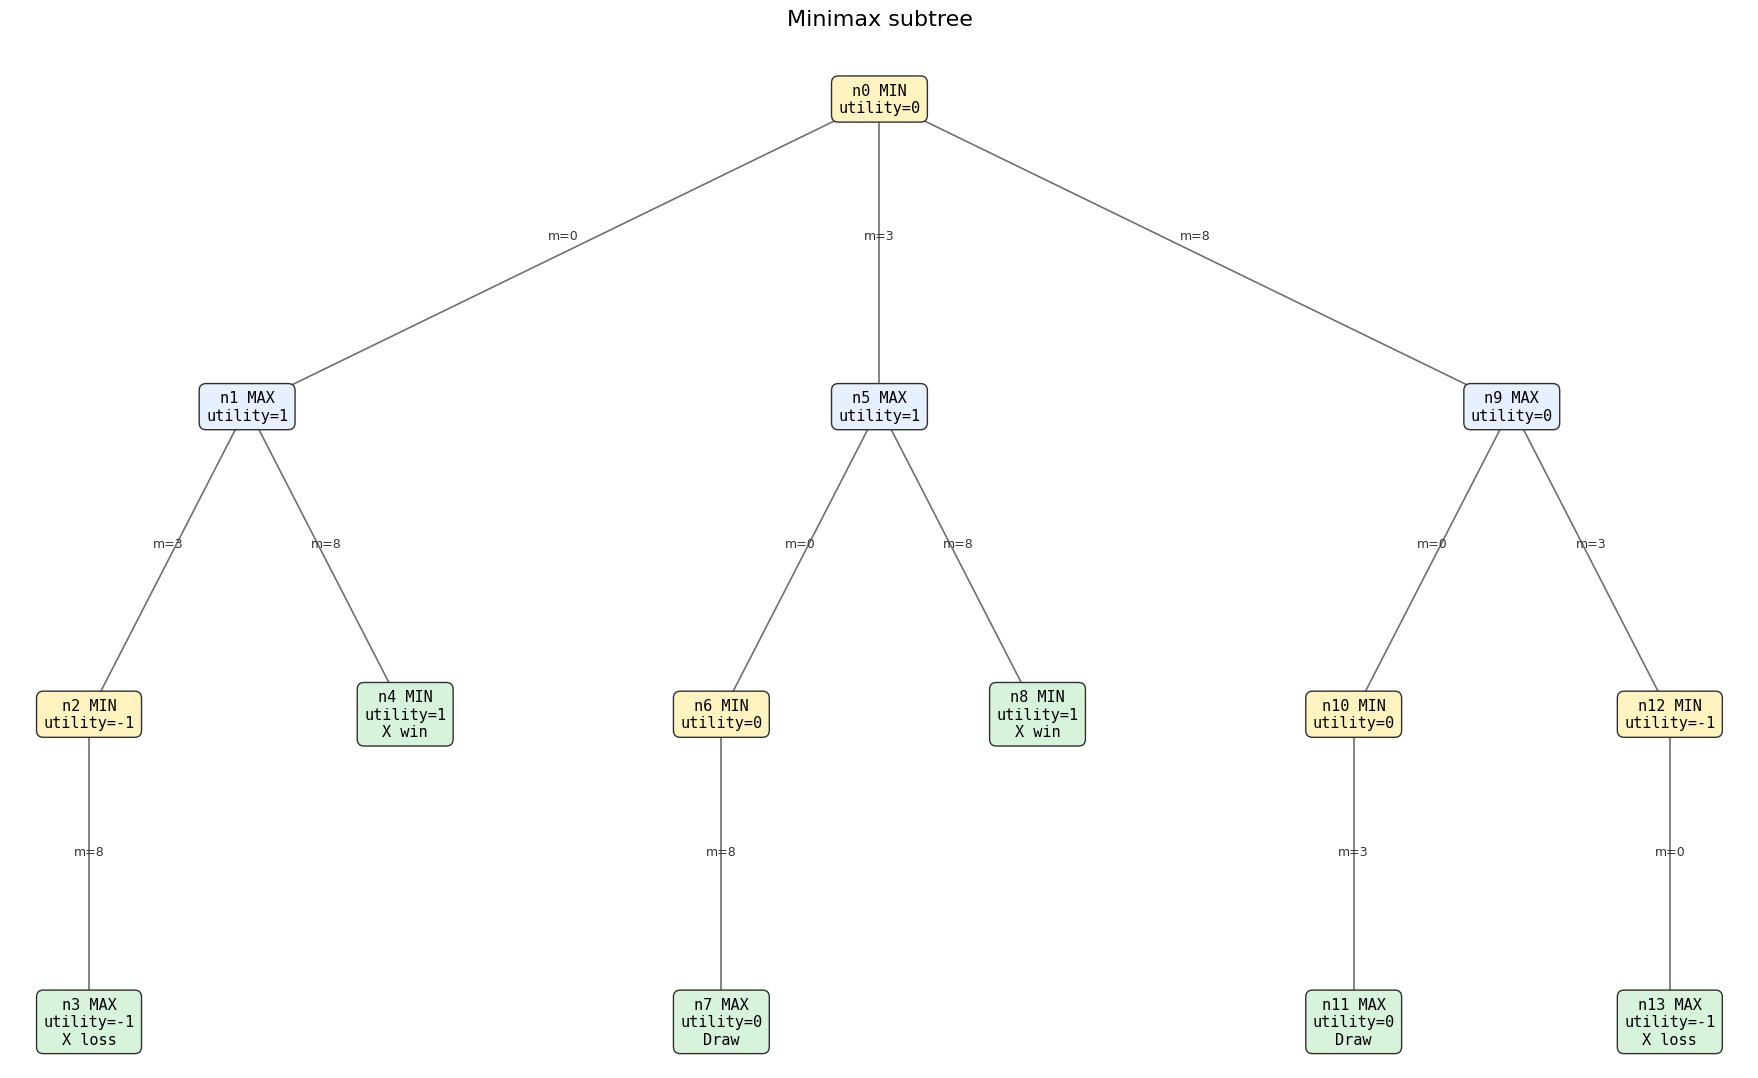

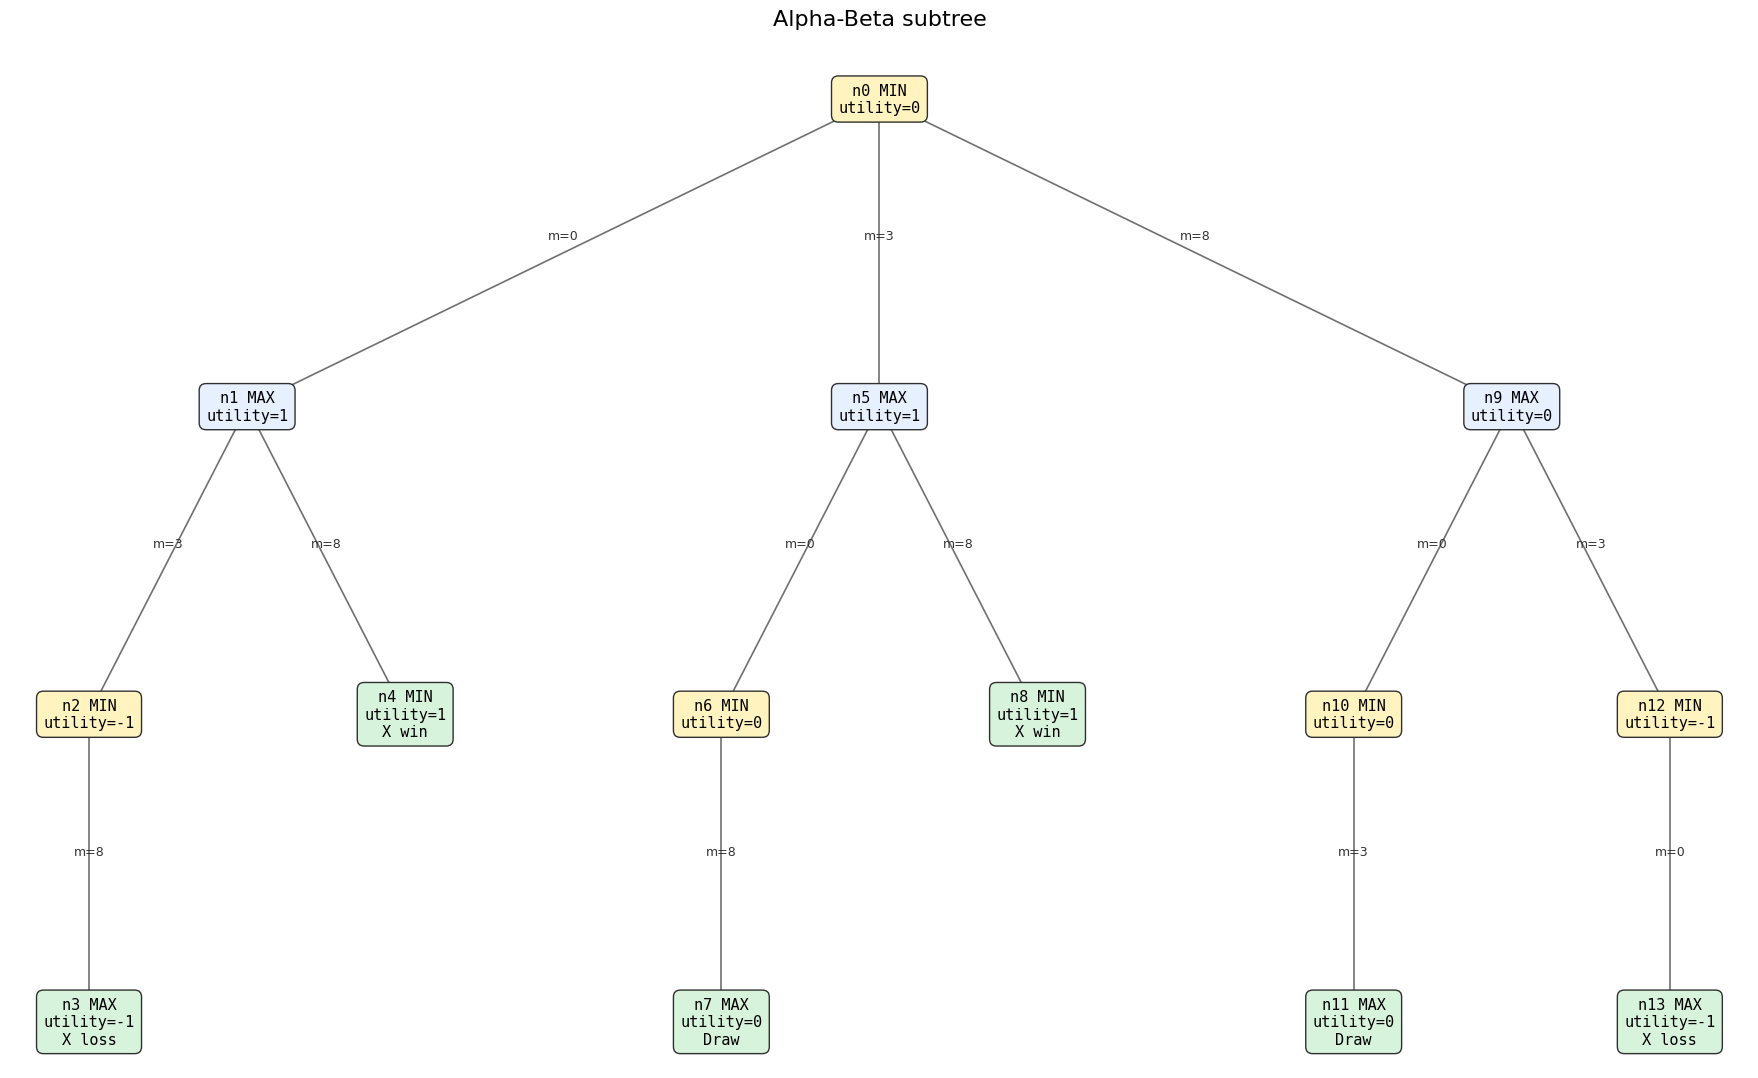

In [48]:
from __future__ import annotations
from dataclasses import dataclass, field
from pathlib import Path
import math
import sys
import matplotlib.pyplot as plt

# Import aima code
aima_directory = Path.cwd().parent / "aima" if Path.cwd().name == "homework" else Path.cwd() / "aima"
if str(aima_directory) not in sys.path:
    sys.path.insert(0, str(aima_directory))
from games import TicTacToe, GameState

# 1) Recreate the exact Figure 1 board state from the HW prompt.
# 2) Force X to play position 5 first
# 3) From that forced state, build two search trees:
#    - Minimax (to terminal leaves)
#    - Alpha-Beta (same minimax logic + pruning bounds)
# 4) Render both trees in plot
#
# state:
#   A single board configuration (who moves next, board marks, legal moves).
#
# utility:
#   Numeric game outcome from X's perspective:
#   +1 = X win, 0 = draw, -1 = X loss.
#
# terminal state / leaf:
#   A finished position (win/loss/draw), so recursion stops there.
#
# MAX node:
#   A turn where the current player is choosing to maximize X's utility.
#
# MIN node:
#   A turn where the opponent is choosing to minimize X's utility.
#   This is from O's perspective
#
# move:
#   One legal action from game.actions(state), represented by board index
#   mapping used in the assignment (0..8).
#
# alpha (lower bound):
#   Best guaranteed value found so far for MAX on the current path.
#
# beta (upper bound):
#   Best guaranteed value found so far for MIN on the current path.
#
# prune:
#   Skip evaluating remaining siblings when they cannot affect the final
#   decision:
#   - At MAX: if utility >= beta, prune rest of siblings.
#   - At MIN: if utility <= alpha, prune rest of siblings.
#
#   Alpha-beta does NOT automatically find best move order. It only prunes
#   according to current action order. If move ordering is poor, pruning can
#   be small (or none), and the explored tree can look very similar to minimax.
#   The problem does not ask to use a heuristic in determining evaluation order #   so I will keep it simple here and not use a heuristic within the alpha-beta.
# ============================================================

# Figure 1 index mapping.
position_index_to_coordinate = {
    0: (1, 1), 1: (2, 1), 2: (3, 1),
    3: (1, 2), 4: (2, 2), 5: (3, 2),
    6: (1, 3), 7: (2, 3), 8: (3, 3),
}
coordinate_to_position_index = {coordinate: index for index, coordinate in position_index_to_coordinate.items()}


def move_to_position_index(move_coordinate):
    """Convert an AIMA move coordinate (x, y) into the HW board index (0..8)."""
    return coordinate_to_position_index[move_coordinate]


def format_board_state(state):
    board_cells = [state.board.get(position_index_to_coordinate[index], ".") for index in range(9)]
    return f"{''.join(board_cells[:3])}|{''.join(board_cells[3:6])}|{''.join(board_cells[6:])}"


def get_available_action_indices(game, state):
    return [move_to_position_index(move_coordinate) for move_coordinate in game.actions(state)]


def get_terminal_outcome_label(game, state, perspective_player="X"):
    utility_value = game.utility(state, perspective_player)
    return "X win" if utility_value == 1 else "X loss" if utility_value == -1 else "Draw"


@dataclass
class SearchTraceNode:
    """Store traced search-node metadata for plotting (type, utility, move, and children)."""
    node_id: int
    kind: str
    depth: int
    state: str
    to_move: str
    player: str
    actions: list
    from_move: int | None = None
    v: int | None = None
    move: int | None = None
    alpha: float | None = None
    beta: float | None = None
    pruned: bool = False
    leaf: bool = False
    leaf_label: str | None = None
    children: list = field(default_factory=list)


def build_figure1_state(game):
    """Reconstruct the exact Figure 1 board as a GameState with X to move."""
    board = {
        position_index_to_coordinate[6]: "O",
        position_index_to_coordinate[1]: "O",
        position_index_to_coordinate[4]: "O",
        position_index_to_coordinate[7]: "X",
        position_index_to_coordinate[2]: "X",
    }
    all_coordinates = [(x, y) for x in range(1, 4) for y in range(1, 4)]
    remaining_moves = [move_coordinate for move_coordinate in all_coordinates if move_coordinate not in board]
    return GameState(to_move="X", utility=0, board=board, moves=remaining_moves)


def trace_minimax_subtree(game, root_state, perspective_player="X"):
    """Trace the minimax subtree recursively and record each visited node.

    max_value selects the child with maximum utility; min_value selects the
    child with minimum utility. Each visited state is saved as SearchTraceNode.
    """
    node_id_counter = 0

    def create_node(**node_fields):
        nonlocal node_id_counter
        node = SearchTraceNode(node_id=node_id_counter, player=perspective_player, **node_fields)
        node_id_counter += 1
        return node

    def max_value(state, depth, from_move):
        node = create_node(
            kind="MAX",
            depth=depth,
            state=format_board_state(state),
            to_move=state.to_move,
            actions=get_available_action_indices(game, state),
            from_move=from_move,
        )
        if game.terminal_test(state):
            node.leaf = True
            node.v = game.utility(state, perspective_player)
            node.leaf_label = get_terminal_outcome_label(game, state, perspective_player)
            return node

        best_value = -math.inf
        best_move_index = None
        for action_move in game.actions(state):
            child_node = min_value(game.result(state, action_move), depth + 1, move_to_position_index(action_move))
            node.children.append(child_node)
            if child_node.v > best_value:
                best_value = child_node.v
                best_move_index = move_to_position_index(action_move)

        node.v = int(best_value)
        node.move = best_move_index
        return node

    def min_value(state, depth, from_move):
        node = create_node(
            kind="MIN",
            depth=depth,
            state=format_board_state(state),
            to_move=state.to_move,
            actions=get_available_action_indices(game, state),
            from_move=from_move,
        )
        if game.terminal_test(state):
            node.leaf = True
            node.v = game.utility(state, perspective_player)
            node.leaf_label = get_terminal_outcome_label(game, state, perspective_player)
            return node

        best_value = math.inf
        best_move_index = None
        for action_move in game.actions(state):
            child_node = max_value(game.result(state, action_move), depth + 1, move_to_position_index(action_move))
            node.children.append(child_node)
            if child_node.v < best_value:
                best_value = child_node.v
                best_move_index = move_to_position_index(action_move)

        node.v = int(best_value)
        node.move = best_move_index
        return node

    return min_value(root_state, depth=0, from_move=5)


def trace_alphabeta_subtree(game, root_state, perspective_player="X"):
    """Trace the alpha-beta subtree with the same minimax recursion plus bounds.

    This carries alpha/beta through recursion and marks nodes where siblings
    are pruned by the cutoff rules.
    """
    node_id_counter = 0

    def create_node(**node_fields):
        nonlocal node_id_counter
        node = SearchTraceNode(node_id=node_id_counter, player=perspective_player, **node_fields)
        node_id_counter += 1
        return node

    def max_value(state, alpha, beta, depth, from_move):
        node = create_node(
            kind="MAX",
            depth=depth,
            state=format_board_state(state),
            to_move=state.to_move,
            actions=get_available_action_indices(game, state),
            from_move=from_move,
            alpha=alpha,
            beta=beta,
        )
        if game.terminal_test(state):
            node.leaf = True
            node.v = game.utility(state, perspective_player)
            node.leaf_label = get_terminal_outcome_label(game, state, perspective_player)
            return node

        best_value = -math.inf
        best_move_index = None
        action_moves = list(game.actions(state))
        for action_offset, action_move in enumerate(action_moves):
            child_node = min_value(
                game.result(state, action_move),
                alpha,
                beta,
                depth + 1,
                move_to_position_index(action_move),
            )
            node.children.append(child_node)
            if child_node.v > best_value:
                best_value = child_node.v
                best_move_index = move_to_position_index(action_move)

            # For MAX, prune when utility >= beta because remaining siblings cannot improve MIN above this bound.
            if best_value >= beta:
                if action_offset < len(action_moves) - 1:
                    node.pruned = True
                break
            alpha = max(alpha, best_value)

        node.v = int(best_value)
        node.move = best_move_index
        node.alpha = alpha
        node.beta = beta
        return node

    def min_value(state, alpha, beta, depth, from_move):
        node = create_node(
            kind="MIN",
            depth=depth,
            state=format_board_state(state),
            to_move=state.to_move,
            actions=get_available_action_indices(game, state),
            from_move=from_move,
            alpha=alpha,
            beta=beta,
        )
        if game.terminal_test(state):
            node.leaf = True
            node.v = game.utility(state, perspective_player)
            node.leaf_label = get_terminal_outcome_label(game, state, perspective_player)
            return node

        best_value = math.inf
        best_move_index = None
        action_moves = list(game.actions(state))
        for action_offset, action_move in enumerate(action_moves):
            child_node = max_value(
                game.result(state, action_move),
                alpha,
                beta,
                depth + 1,
                move_to_position_index(action_move),
            )
            node.children.append(child_node)
            if child_node.v < best_value:
                best_value = child_node.v
                best_move_index = move_to_position_index(action_move)

            # For MIN, prune when utility <= alpha because remaining siblings cannot improve MAX above this bound.
            if best_value <= alpha:
                if action_offset < len(action_moves) - 1:
                    node.pruned = True
                break
            beta = min(beta, best_value)

        node.v = int(best_value)
        node.move = best_move_index
        node.alpha = alpha
        node.beta = beta
        return node

    return min_value(root_state, -math.inf, math.inf, depth=0, from_move=5)

def draw_tree(root_node, title):
    """Render a game-tree diagram from a traced root node.

    The function traverses all nodes, computes a layered (depth-based) layout,
    draws parent-child edges with move labels, and then draws compact node boxes
    with utility and terminal outcome text for visualization.
    """
    all_nodes = []

    def collect_nodes(node):
        all_nodes.append(node)
        for child_node in node.children:
            collect_nodes(child_node)

    collect_nodes(root_node)

    node_coordinates = {}
    next_x_coordinate = 0.0
    horizontal_spacing = 2.5
    vertical_spacing = 2.2

    def place_nodes(node):
        nonlocal next_x_coordinate
        if not node.children:
            node_coordinates[node.node_id] = (next_x_coordinate, -node.depth * vertical_spacing)
            next_x_coordinate += horizontal_spacing
            return node_coordinates[node.node_id][0]

        child_x_positions = [place_nodes(child_node) for child_node in node.children]
        node_coordinates[node.node_id] = (
            sum(child_x_positions) / len(child_x_positions),
            -node.depth * vertical_spacing,
        )
        return node_coordinates[node.node_id][0]

    place_nodes(root_node)

    leaf_count = sum(1 for node in all_nodes if not node.children)
    max_depth = max(node.depth for node in all_nodes)
    figure_width = max(18, 2.8 * leaf_count)
    figure_height = max(10, 2.8 * (max_depth + 1))

    # Create the matplotlib figure/canvas and one axes for drawing.
    figure, axis = plt.subplots(figsize=(figure_width, figure_height))
    axis.set_title(title, fontsize=16, pad=20)
    axis.axis("off")

    for parent_node in all_nodes:
        parent_x, parent_y = node_coordinates[parent_node.node_id]
        for child_node in parent_node.children:
            child_x, child_y = node_coordinates[child_node.node_id]
            # Draw the edge from parent node to child node.
            axis.plot([parent_x, child_x], [parent_y, child_y], color="#707070", linewidth=1.2)
            # Draw the move label along each edge.
            axis.text(
                (parent_x + child_x) / 2,
                (parent_y + child_y) / 2 + 0.12,
                f"m={child_node.from_move}",
                fontsize=9,
                ha="center",
                va="center",
                color="#333333",
            )

    for node in all_nodes:
        x_coordinate, y_coordinate = node_coordinates[node.node_id]
        node_color = "#ffd6d6" if node.pruned else "#d8f3dc" if node.leaf else "#e7f0ff" if node.kind == "MAX" else "#fff3bf"

        label_lines = [
            f"n{node.node_id} {node.kind}",
            f"utility={node.v}",
        ]
        if node.leaf:
            label_lines.append(node.leaf_label)

        node_label = "\n".join(label_lines)

        # Draw the node box label at the node coordinates.
        axis.text(
            x_coordinate,
            y_coordinate,
            node_label,
            fontsize=11,
            linespacing=1.2,
            family="monospace",
            ha="center",
            va="center",
            bbox={
                "boxstyle": "round,pad=0.45",
                "facecolor": node_color,
                "edgecolor": "#303030",
                "linewidth": 1.0,
            },
        )
    figure.tight_layout(pad=2.2)
    plt.show()


game = TicTacToe()
figure1_initial_state = build_figure1_state(game)
forced_state_after_x5 = game.result(figure1_initial_state, position_index_to_coordinate[5])

minimax_root = trace_minimax_subtree(game, forced_state_after_x5, perspective_player="X")
alphabeta_root = trace_alphabeta_subtree(game, forced_state_after_x5, perspective_player="X")

draw_tree(minimax_root, "Minimax subtree")
draw_tree(alphabeta_root, "Alpha-Beta subtree")

# Note that the utility values at the nodes are always from X's perspective and the edge labels are the move indices using the specified board numbers.


# Q3 — Inference in Bayesian Networks

## 40 points total

Consider the following Bayesian network representing a simplified medical diagnosis scenario:

- Flu ($F$): binary variable (Yes/No)
- Cold ($C$): binary variable (Yes/No)
- Fever ($Fe$): depends on Flu and Cold
- Cough ($Co$): depends on Cold
- Fatigue ($Fa$): depends on Flu

**Conditional Probability Tables (CPTs)**
- Prior probabilities:
    - $P$($F$ = Yes) = 0.05, $P$($F$ = No) = 0.95
    - $P$($C$ = Yes) = 0.10, $P$($C$ = No) = 0.90
- Conditional distributions:
    - $P$($Fe$ = Yes | $F$, $C$):
        - Flu = Yes, Cold = Yes → 0.90
        - Flu = Yes, Cold = No → 0.80
        - Flu = No, Cold = Yes → 0.70
        - Flu = No, Cold = No → 0.05
    - $P$($Co$ = Yes | Cold):
        - Cold = Yes → 0.80
        - Cold = No → 0.10
    - $P$($Fa$ = Yes | Flu):
        - Flu = Yes → 0.75
        - Flu = No → 0.20


### [10 points] Exact Inference

Compute the posterior probability that a patient has Flu, given that they present with Fever = Yes and Cough = Yes.

$$P(F = \text{Yes} | Fe = \text{Yes}, Co = \text{Yes})$$

### [15 points] Approximate Inference
Outline how you would estimate the same posterior using Likelihood Weighting. Describe:
- How you would generate samples
- How weights are assigned
- How the posterior is approximated from weighted samples

### [15 points] Extension to Dynamic Bayesian Networks (DBNs):
Suppose this model is extended across two consecutive days, where $Flu(t)$ influences $Flu(t+1)$ with transition probability

$$ 
P(F(t+1) = \text{Yes} | F(t) = \text{Yes}) = 0.80, P(F(t+1) = \text{Yes} | F(t) = \text{No}) = 0.10 
$$

Describe how inference would change if you wanted to compute the probability that the patient has the flu on Day 2, given observations $(Fe = \text{Yes}, Co = \text{Yes})$ on Day 1.


## Response

### **Exact Inference**
- Given general bayesian network rule: $P(X_1, \ldots, X_n) = \prod_i P(X_i \mid \text{Parents}(X_i))$
- F has no parents -- $P(F)$
- C has no parents -- $P(C)$
- Fe has parents $(F,C)$ so $P(Fe | F,C)$
- Co has parent $(C)$ so $P(Co |C)$
- Fa has parent $(F)$ so $P(Fa | F)$
- Evidence: $Fe = Yes, Co = Yes$
- Query: $P(F = \text{Yes} \mid Fe = \text{Yes}, Co = \text{Yes})$ -- In english: out of all worlds where fever adn cough are true, what is the probability a person has the flue?
- Posterior definition:
$$
P(F \mid e) = \dfrac{P(F, e)}{P(e)}
$$
- $P(F, e) = \sum_{C} \sum_{Fa} P(F, C, Fe = \text{Yes}, Co = \text{Yes}, Fa)$
- Re-writing the joint probability distribution 
$$
P(F,e)=\sum_{C}\sum_{Fa} P(F)\,P(C)\,P(Fe=\text{Yes}\mid F,C)\,P(Co=\text{Yes}\mid C)\,P(Fa\mid F)
$$
- Since summing over Fa means adding over all possible values of fatigue, and nothing excet $P(Fa\mid F)$ depends on Fa, we can factor it out because it equals 1:
$$
P(F,e)=P(F)\sum_{C} P(C)\,P(Fe=\text{Yes}\mid F,C)\,P(Co=\text{Yes}\mid C)
$$
- Computing F = yes case: 
$$
0.05\,[0.10(0.90)(0.80)+0.90(0.80)(0.10)]
=0.05(0.072+0.072)=0.0072
$$
- Computing the F = no case:
$$
0.95\,[0.10(0.70)(0.80)+0.90(0.05)(0.10)]
=0.95(0.056+0.0045)=0.057475
$$
- Normalizing for the specific query:
$$
P(F=\text{Yes}\mid e)=\frac{0.0072}{0.0072+0.057475}=0.1113
$$

### **Approximate Inference (Likelihood Weighting)**

I follow the AIMA likelihood-weighting process for the query

$$
P(F=\text{Yes} \mid Fe=\text{Yes}, Co=\text{Yes})
$$

with evidence

$$
e = \{Fe=\text{Yes},\ Co=\text{Yes}\}
$$

and topological order:

$$
F,\ C,\ Fe,\ Co,\ Fa
$$

#### Pseudocode

1. Initialize weight: $w \leftarrow 1.0$.
2. For each variable in order $F, C, Fe, Co, Fa$:
   - If variable is evidence, set it to the evidence value and multiply weight by its conditional probability.
   - If variable is not evidence, sample it from its conditional distribution given already-set parents.
3. Return one weighted event $(x, w)$.
4. Repeat for many samples.
5. Accumulate weighted counts for query values:
   - $W_{yes} = \sum w_i$ for samples with $F=\text{Yes}$
   - $W_{no} = \sum w_i$ for samples with $F=\text{No}$
6. Normalize:

$$
P(F=\text{Yes}\mid e) \approx \frac{W_{yes}}{W_{yes}+W_{no}}.
$$

**Walkthrough**
- Start: $w=1.0$

1. $F$ is not evidence. Sample from $P(F=\text{Yes})=0.05$.  
   Suppose sampled value is $F=\text{No}$.
2. $C$ is not evidence. Sample from $P(C=\text{Yes})=0.10$.  
   Suppose sampled value is $C=\text{Yes}$.
3. $Fe$ is evidence with value Yes. Update weight:

$$
w \leftarrow w \times P(Fe=\text{Yes} \mid F=\text{No}, C=\text{Yes}) = 1.0 \times 0.70 = 0.70
$$

4. $Co$ is evidence with value Yes. Update weight:

$$
w \leftarrow w \times P(Co=\text{Yes} \mid C=\text{Yes}) = 0.70 \times 0.80 = 0.56
$$

5. $Fa$ is not evidence. Sample from $P(Fa \mid F=\text{No})$ (does not change weight).

- Returned sample event has weight $0.56$ and is tallied under $F=\text{No}$.
- This means that the likelihood of this sample with this evidence is 0.56
- More efficient than rejection sampling because we're not rejecting a sample if the evidence doesn't match outright
#### Running estimate update

For each generated weighted sample $(x_i, w_i)$:
- if $F=\text{Yes}$ in $x_i$, add $w_i$ to $W_{yes}$
- else add $w_i$ to $W_{no}$

- After $N$ samples:

$$
\hat{P}(F=\text{Yes}\mid Fe=\text{Yes},Co=\text{Yes}) = \frac{W_{yes}}{W_{yes}+W_{no}}.
$$

### **Extension to DBNs**
- Now time exists
- We need to compute $P(F_2 = Yes | e_1)$
- From part 1, we computed $P(F_1 = \text{Yes} \mid e_1) = 0.1113$ and $P(f_1 = \text{No} \mid e1) = 0.8887$
- This is our given transition model: 
$$ 
P(F(t+1) = \text{Yes} | F(t) = \text{Yes}) = 0.80, P(F(t+1) = \text{Yes} | F(t) = \text{No}) = 0.10 
$$
- So now the inference is a two stage process:
   1. Use filtering to update our current real time estimate
      - Infer what we believe about the flu on Day 1
   2. Propogate forward using the transition model

$$
P(F_2=\text{Yes}\mid e_1)
= P(F_2=\text{Yes}\mid F_1=\text{Yes})\,P(F_1=\text{Yes}\mid e_1)
+ P(F_2=\text{Yes}\mid F_1=\text{No})\,P(F_1=\text{No}\mid e_1)
$$

$$
= 0.80(0.1113) + 0.10(0.8887) = 0.1779
$$